# Symbolisches Rechnen mit `SymPy`
- `SymPy` ist eine Python-Bibliothek für symbolisches Rechnen.
- Es ermöglicht die Manipulation und Vereinfachung von mathematischen Ausdrücken, das Lösen von Gleichungen, das Differenzieren und Integrieren von Funktionen und vieles mehr.
- `SymPy` ist besonders nützlich für Aufgaben, die über numerische Berechnungen hinausgehen und eine symbolische Darstellung erfordern.
- Installation: `pip install sympy` 


## Definieren von Symbolen (= Unbekannten)
Die Funktion `symbols` wird verwendet, um symbolische Variablen zu definieren. Diese Variablen können dann in mathematischen Ausdrücken verwendet werden.

```python
from sympy import symbols
x, y = symbols('display_name_x display_name_y')
```

- Hier sind `x` und `y` symbolische Variablen, die in späteren Berechnungen verwendet werden können.
- Die Argumente von `symbols` sind die Namen, die in der Ausgabe verwendet werden. Sie können von den Variablennamen im Code abweichen.
- Im Unterschied zu normalen Python-Variablen können symbolische Variablen nicht direkt mit Zahlen oder anderen Variablen verknüpft werden. Stattdessen werden sie in Ausdrücken verwendet, die später ausgewertet oder manipuliert werden können.

In [2]:
from sympy import symbols
x, y = symbols('x y')
expr = x**2 + 2*x*y + y**2
print(expr*expr)

(x**2 + 2*x*y + y**2)**2


## Auswerten von Ausdrücken
Die Funktion `evalf()` wird verwendet, um symbolische Ausdrücke numerisch auszuwerten.
- Jede Variable im Ausdruck muss zuvor definiert worden sein.
- Die Werte der Variablen werden als Dictionary übergeben, wobei die Schlüssel die symbolischen Variablen und die Werte die numerischen Werte sind.

In [3]:
print("Let x = 1 and y = 2. Then,", expr, "=", expr.evalf(subs={x: 1, y: 2})) 

Let x = 1 and y = 2. Then, x**2 + 2*x*y + y**2 = 9.00000000000000


`SymPy` rechnet intern mit der Klasse `Float`, die eine höhere Präzision als die Standard-Python-Gleitkommazahlen bietet. 
- `SymPy` versucht automatisch den Rundungsfehler zu schätzen und die Präzision der Berechnungen zu erhöhen, wenn dies erforderlich ist.

## Substitution von Variablen
Die Methode `subs()` wird verwendet, um symbolische Variablen in einem Ausdruck durch andere Ausdrücke oder Werte zu ersetzen.
- Sie nimmt ein Dictionary als Argument, in dem die Schlüssel die zu ersetzenden Variablen und die Werte die neuen Ausdrücke oder Werte sind.
- Will man nur eine Variable ersetzen, kann `subs` auch mit zwei Argumenten aufgerufen werden: `expr.subs(old, new)`.
- Wenn alle Variablen durch numerische Werte ersetzt wurden, kann der Ausdruck mit `evalf()` ausgewertet werden.

In [3]:
a, b = symbols('a b')
expr2 = expr.subs({x: a + 1, y: b - 1})
print("After substitution:", expr2)
print("After substitution and evaluation at a=1, b=2:", expr2.subs({a: 1, b: 2}).evalf())

After substitution: (a + 1)**2 + 2*(a + 1)*(b - 1) + (b - 1)**2
After substitution and evaluation at a=1, b=2: 9.00000000000000


## Manipulation von Ausdrücken
`SymPy` bietet eine Vielzahl von Funktionen zur Manipulation und Vereinfachung von Ausdrücken, wie z.B. `expand()`, `factor()`, `simplify()`, etc
- `expand()`: Rechnet Produkte aus und entwickelt Potenzen
- `factor()`: Faktorisierung von Ausdrücken
- `simplify()`: Versucht, den Ausdruck zu vereinfachen

In [4]:
expr = (x + y)**2
expr2 = x**3 + 3*x**2*y + 3*x*y**2 + y**3
print("Expanded:", expr, "=", expr.expand())
print("Factored:", expr2, "=", expr2.factor())
print("Simplified:", (x**2 - y**2)/(x - y), "=", ((x**2 - y**2)/(x - y)).simplify())


Expanded: (x + y)**2 = x**2 + 2*x*y + y**2
Factored: x**3 + 3*x**2*y + 3*x*y**2 + y**3 = (x + y)**3
Simplified: (x**2 - y**2)/(x - y) = x + y


- `collect()`: Sammelt Terme mit gemeinsamen Faktoren
- `collect(x)`: Sammelt Terme mit gemeinsamen Faktoren in Bezug auf `x'

In [5]:
from sympy import collect, together, apart

# Example for collect
expr3 = x**2 + 2*x*y + y**2 + x*y + x*y**2
collected_expr = collect(expr3, x)
print("Collected with respect to x:", collected_expr)



Collected with respect to x: x**2 + x*(y**2 + 3*y) + y**2


## Mathematische Funktionen in `SymPy`
`SymPy` bietet eine Vielzahl von mathematischen Funktionen, die in symbolischen Ausdrücken verwendet werden können. Einige der wichtigsten Funktionen sind:
- Trigonometrische Funktionen: `sin()`, `cos()`, `tan()`, `asin()`, `acos()`, `atan()`
- Exponential- und Logarithmusfunktionen: `exp()`, `log()`
- Hyperbolische Funktionen: `sinh()`, `cosh()`, `tanh()`
- Spezielle Funktionen: `gamma()`, `erf()`, `besselj()`, etc.

In [6]:
from sympy import sin, cos
expr = sin(x)**2 + cos(x)**2
print("sin(x)^2 + cos(x)^2 =", expr.simplify())

sin(x)^2 + cos(x)^2 = 1


## Lösen von Gleichungen
Die Funktion `solve()` wird verwendet, um Gleichungen der folgenden Form symbolisch zu lösen:

```python
 Expression of Equation = 0
```
- Sie nimmt die Ausdrücke der Gleichung (oder eines Systems von Gleichungen als Liste ) und die Variable(n), die gelöst werden sollen, als Argumente
- `solve()` gibt die Lösungen als Liste zurück 
    - bei mehreren Variablen als Dictionary
    - bei mehreren Lösungen und mehreren Variablen als Liste von Tupeln
- Die rechte Seite der Gleichung wird implizit als 0 angenommen, d.h. die Gleichung $x^2 = 4$ muss zuerst umgeformt werden zu $x^2 - 4 = 0$.


In [6]:
from sympy import solve, symbols
x,y, z = symbols('x y z')
sols = solve(x**2 - 4*z, x)
print("Solutions of x^2 - 4 = 0:", sols)
sols = solve([x**2-4, y**2-1], (x, y))
print("Solutions of the system of equations x^2 = 4 and y^2 = 1:", sols)
sols = solve([x + y - 3, x - y - 1], (x, y))
print("Solutions of the system of equations x + y = 3 and x - y = 1:", sols)

Solutions of x^2 - 4 = 0: [-2*sqrt(z), 2*sqrt(z)]
Solutions of the system of equations x^2 = 4 and y^2 = 1: [(-2, -1), (-2, 1), (2, -1), (2, 1)]
Solutions of the system of equations x + y = 3 and x - y = 1: {x: 2, y: 1}


### Welche Gleichungen können gelöst werden?
`solve` kann viele, aber bei weitem nicht alle Gleichungen lösen. Unter anderem können folgende Typen von Gleichungen gelöst werden:
- Polynomiale Gleichungen (z.B. quadratische, kubische Gleichungen)
- Lineare Gleichungssysteme
- Einige spezielle Funktionen (z.B. Exponential-, Logarithmus-, Trigonometrische Funktionen)
- Rationale Gleichungen (Brüche von Polynomen)

Für komplexere Gleichungen oder Gleichungssysteme kann es notwendig sein, spezialisierte Funktionen oder numerische Methoden zu verwenden.

In [9]:
from sympy import exp
sols = solve(x*exp(x)-y, x)
print("Solutions of x^6 - x^3 - 2 = 0:", sols)

Solutions of x^6 - x^3 - 2 = 0: [LambertW(y)]


### Beispiel: Interpolation
Die Aufgabe der Interpolation besteht darin, eine Funktion zu finden, die durch eine gegebene Menge von Punkten verläuft.
Ein quadratisches Polynom kann durch drei Punkte eindeutig bestimmt werden, und daher auch drei Punkte interpolieren.

Wir suchen also ein Polynom der Form $p(x) = a x^2 + b x + c$, das durch die Punkte $(x_0, y_0)$, $(x_1, y_1)$ und $(x_2, y_2)$ verläuft.
$$
p(x_i) = y_i \quad \text{für } i = 0, 1, 2
$$

Interpolating polynomial: -3*x**2/2 + 5*x/2 + 1


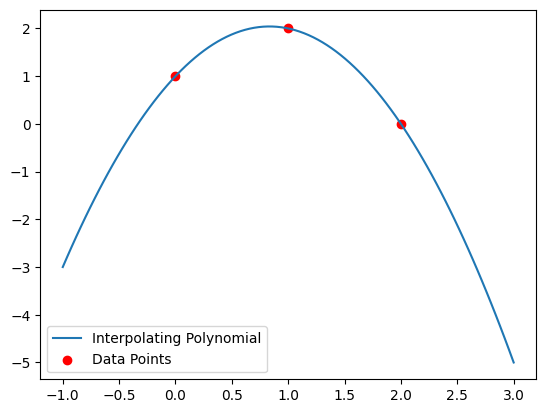

In [9]:
import sympy as sp 
x, a, b, c = sp.symbols('x a b c')
points =  [(0, 1), (1, 2), (2, 0)]
p = a*x**2 + b*x + c
equations = [p.subs(x, xi) - yi for xi, yi in points]
solutions = sp.solve(equations, (a, b, c))
p_interpolating = p.subs(solutions)
print("Interpolating polynomial:", p_interpolating)

# Plotting the points and the polynomial
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(-1, 3, 100)
y_vals = [p_interpolating.evalf(subs={x : val}) for val in x_vals]
plt.plot(x_vals, y_vals, label='Interpolating Polynomial')
px, py = zip(*points)
plt.scatter(px, py, color='red', label='Data Points')
plt.legend()
plt.show()



### Alternative: `interpolate` Funktion
Anstatt die Interpolation manuell durchzuführen, können wir die `interpolate` Funktion von SymPy verwenden, um das gleiche Ergebnis zu erzielen.


In [10]:
p = sp.interpolate(points, x)
print("Interpolating polynomial using interpolate function:", p)

Interpolating polynomial using interpolate function: -3*x**2/2 + 5*x/2 + 1


## Differenzieren und Integrieren
`SymPy` bietet Funktionen zum symbolischen Differenzieren und Integrieren von Ausdrücken:
- `diff()`: Differenziert einen Ausdruck nach einer oder mehreren Variablen
- `integrate()`: Integriert einen Ausdruck nach einer oder mehreren Variablen


In [13]:
from sympy import sin, cos
import sympy as sp
a, b = symbols('a b')
f = 1/(sin(x)+cos(x))
f_diff = sp.diff(f, x)
f_int = sp.integrate(f, x)
print("Function:", f)
print("Derivative:", f_diff)
print("Indefinite Integral:", f_int)
print("Integral from a to b:", sp.integrate(f, (x, a, b)))

Function: 1/(sin(x) + cos(x))
Derivative: (sin(x) - cos(x))/(sin(x) + cos(x))**2
Indefinite Integral: sqrt(2)*log(tan(x/2) - 1 + sqrt(2))/2 - sqrt(2)*log(tan(x/2) - sqrt(2) - 1)/2
Integral from a to b: -sqrt(2)*log(tan(a/2) - 1 + sqrt(2))/2 + sqrt(2)*log(tan(a/2) - sqrt(2) - 1)/2 + sqrt(2)*log(tan(b/2) - 1 + sqrt(2))/2 - sqrt(2)*log(tan(b/2) - sqrt(2) - 1)/2


### Beispiel: Textaufgabe
Finden Sie eine Parabel, die durch die den Hochpunkt bei $x=0$ hat, Nullstellen bei $x=-1$ und $x=1$, und welche mit der $x$-Achse eine Fläche von 2 einschließt.

Parabel: 3/2 - 3*x**2/2


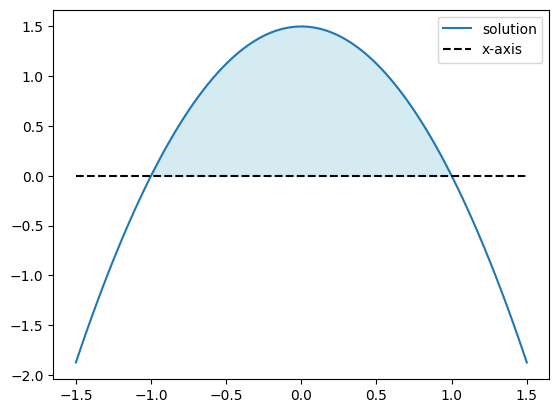

In [12]:
import sympy as sp
x, a, b, c = sp.symbols('x a b c')
f = a*(x**2) + b*x + c
# Hochpunkt bei x=0 => f'(0) = 0
eq1 = sp.diff(f,x).subs(x, 0)
# Nullstellen bei x=-1 und x=1 => f(-1) = 0 und f(1) = 0
eq2a = f.subs(x, -1)
eq2b = f.subs(x, 1)
# Fläche von 2 mit der x-Achse => Integral von f 
eq3 = sp.integrate(f, (x, -1, 1)) - 2

solutions = sp.solve([eq1, eq2a, eq2b, eq3], (a, b, c))
f_solution = f.subs(solutions)
print("Parabel:", f_solution)

# Plotting the solution
import numpy as np
import matplotlib.pyplot as plt
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = np.array([f_solution.evalf(subs={x : val}) for val in x_vals], dtype=np.float64)
plt.plot(x_vals, y_vals, label='solution')
plt.plot(x_vals, np.zeros_like(x_vals), 'k--', label='x-axis')
plt.fill_between(x_vals, y_vals, where=(y_vals > 0), color='lightblue', alpha=0.5)
plt.legend()
plt.show()
